In [19]:
# ==============================================================================
# SECTION 1: IMPORTING LIBRARIES
# ==============================================================================

# Core data handling libraries
import pandas as pd
import numpy as np

# Data splitting and machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Machine Learning model
import lightgbm as lgb

# Saving the final model weights
import joblib

# Charting and visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set charts to look nice and clean
sns.set_theme(style="whitegrid")

print("✅ Section 1 Complete: All basic libraries imported successfully!")

✅ Section 1 Complete: All basic libraries imported successfully!


In [20]:
# ==============================================================================
# SECTION 2: LOADING THE DATASET
# ==============================================================================

# Define the local file path where your CSV is saved
file_path = "/content/ai_student_impact_dataset (1).csv"

# Load the file into a pandas DataFrame
df = pd.read_csv(file_path)

# Drop 'Student_ID' because it is just a random identifier and won't help the model learn
if 'Student_ID' in df.columns:
    df = df.drop(columns=['Student_ID'])

# Print basic information to verify everything loaded correctly
print("📊 Dataset Summary:")
print(f"Total Rows (Students): {df.shape[0]}")
print(f"Total Columns (Features): {df.shape[1]}")
print("\n📋 List of all columns in your dataset:")
print(list(df.columns))

# Show the first 3 rows so we can look at the raw data values
print("\n👀 Preview of the first 3 rows:")
df.head(3)

📊 Dataset Summary:
Total Rows (Students): 50000
Total Columns (Features): 15

📋 List of all columns in your dataset:
['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']

👀 Preview of the first 3 rows:


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium


In [21]:
# ==============================================================================
# SECTION 3.1: BASIC INFRASTRUCTURE INSPECTION & TARGET PREVIEW
# ==============================================================================

print("🔍 Checking for missing values across all columns:")
print(df.isnull().sum())

print("\n📊 Checking target class balance (Burnout_Risk_Level):")
print(df['Burnout_Risk_Level'].value_counts())

print("\n💡 Target class percentage split:")
print(df['Burnout_Risk_Level'].value_counts(normalize=True) * 100)

🔍 Checking for missing values across all columns:
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

📊 Checking target class balance (Burnout_Risk_Level):
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64

💡 Target class percentage split:
Burnout_Risk_Level
Medium    42.288
Low       32.738
High      24.974
Name: proportion, dtype: float64


/tmp/ipykernel_3704/3785594956.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Burnout_Risk_Level', order=['Low', 'Medium', 'High'], palette='muted')


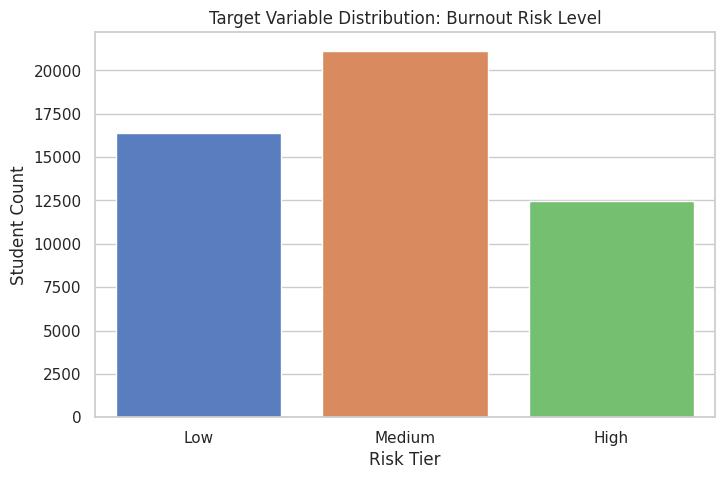

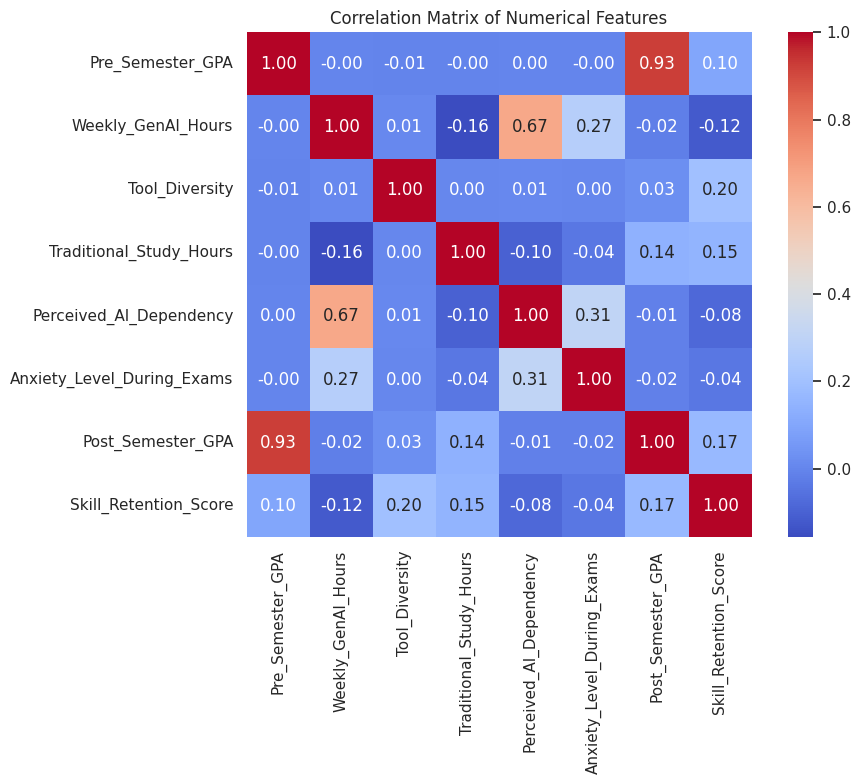

In [22]:
# ==============================================================================
# SECTION 3.2: PLOTTING CORE SYSTEM DISTRIBUTIONS
# ==============================================================================

# Chart 1: Visualizing how the target variable is distributed
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Burnout_Risk_Level', order=['Low', 'Medium', 'High'], palette='muted')
plt.title('Target Variable Distribution: Burnout Risk Level')
plt.xlabel('Risk Tier')
plt.ylabel('Student Count')
plt.show()

# Chart 2: Visualizing correlations between numerical indicators
# We temporarily select only columns with number types to prevent errors
numerical_columns = df.select_dtypes(include=['float64', 'float32', 'int64', 'int32'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_columns.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [23]:
# ==============================================================================
# SECTION 4: DATA PREPROCESSING & CATEGORICAL ENCODING
# ==============================================================================

# Create a copy of the dataframe to keep our raw data safe
df_processed = df.copy()

# 1. Identify which columns are text-based (categorical)
text_columns = ['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
                'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']

# Create a dictionary to save our encoders for later use in the API
saved_encoders = {}

print("🔄 Encoding text columns into numbers:")
for col in text_columns:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    saved_encoders[col] = le
    print(f"   ✓ '{col}' encoded successfully! Classes mapped: {list(le.classes_)}")

# 2. Identify which columns are continuous numbers that need scaling
numeric_columns = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours',
                   'Tool_Diversity', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams',
                   'Post_Semester_GPA', 'Skill_Retention_Score']

print("\n📐 Scaling numeric columns to a standard range...")
scaler = StandardScaler()
df_processed[numeric_columns] = scaler.fit_transform(df_processed[numeric_columns].astype('float32'))
print("   ✓ Numeric columns standardized successfully!")

print("\n👀 Preview of our fully preprocessed dataset (first 2 rows):")
df_processed.head(2)

🔄 Encoding text columns into numbers:
   ✓ 'Major_Category' encoded successfully! Classes mapped: ['Arts', 'Business', 'Humanities', 'Medical', 'STEM']
   ✓ 'Year_of_Study' encoded successfully! Classes mapped: ['Freshman', 'Graduate', 'Junior', 'Senior', 'Sophomore']
   ✓ 'Primary_Use_Case' encoded successfully! Classes mapped: ['Copywriting/Drafting', 'Debugging/Troubleshooting', 'Direct_Answer_Generation', 'Ideation', 'Summarizing_Reading']
   ✓ 'Prompt_Engineering_Skill' encoded successfully! Classes mapped: ['Advanced', 'Beginner', 'Intermediate']
   ✓ 'Institutional_Policy' encoded successfully! Classes mapped: ['Actively_Encouraged', 'Allowed_With_Citation', 'Strict_Ban']
   ✓ 'Burnout_Risk_Level' encoded successfully! Classes mapped: ['High', 'Low', 'Medium']

📐 Scaling numeric columns to a standard range...
   ✓ Numeric columns standardized successfully!

👀 Preview of our fully preprocessed dataset (first 2 rows):


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,2,3,-1.520524,1.799675,0,1,-1.51536,True,-0.597178,0.820873,1,0.806532,-1.929316,0.801256,0
1,3,2,1.409415,-0.883709,3,0,1.85162,False,1.055146,-0.277549,1,2.205756,0.699462,-0.482485,1


In [24]:
# ==============================================================================
# SECTION 5: TRAIN-TEST SPLITTING & FEATURE ISOLATION
# ==============================================================================

# 1. Isolate the input features (X) and drop targets/leakage columns
# We drop Burnout_Risk_Level because it's our target, and Post_Semester_GPA to avoid target leakage.
X = df_processed.drop(columns=['Burnout_Risk_Level', 'Post_Semester_GPA'])

# 2. Isolate the target label (y)
y = df_processed['Burnout_Risk_Level']

# 3. Split data into Training (80%) and Testing (20%) sets
# We use 'stratify=y' to make sure the target distribution matches exactly in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("✂️ Data Split Complete:")
print(f"   • Total input columns to be used for training: {len(X.columns)}")
print(f"   • Columns list: {list(X.columns)}")
print(f"   • Training Features Shape: {X_train.shape}")
print(f"   • Training Labels Shape:   {y_train.shape}")
print(f"   • Testing Features Shape:  {X_test.shape}")
print(f"   • Testing Labels Shape:    {y_test.shape}")

✂️ Data Split Complete:
   • Total input columns to be used for training: 13
   • Columns list: ['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Skill_Retention_Score']
   • Training Features Shape: (40000, 13)
   • Training Labels Shape:   (40000,)
   • Testing Features Shape:  (10000, 13)
   • Testing Labels Shape:    (10000,)


In [25]:
# ==============================================================================
# SECTION 6: MODEL TRAINING AND TESTING
# ==============================================================================

print("🏋️ Training the LightGBM Classifier model...")

# 1. Initialize the standard LightGBM Classifier
# We set a random state to make sure the results are exactly reproducible
model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

# 2. Fit the model onto our training data sets
model.fit(X_train, y_train)
print("✅ Training complete!")

# 3. Test the model using our held-out test data
print("\n🎯 Evaluating model on unseen test data...")
y_pred = model.predict(X_test)

# 4. Extract class names from our saved target encoder to print human-readable metrics
target_labels = list(saved_encoders['Burnout_Risk_Level'].classes_)

print("\n📊 --- Final Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_labels))

print("🧮 --- Confusion Matrix Matrix Breakdown ---")
matrix = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(matrix, index=[f"True_{c}" for c in target_labels], columns=[f"Pred_{c}" for c in target_labels]))

# 5. Save the compiled model and encoders for the production API later
pipeline_artifacts = {
    'model': model,
    'encoders': saved_encoders,
    'feature_names': list(X.columns)
}
joblib.dump(pipeline_artifacts, 'student_risk_pipeline.pkl')
print("\n💾 Core pipeline weights saved successfully as 'student_risk_pipeline.pkl'!")

🏋️ Training the LightGBM Classifier model...
✅ Training complete!

🎯 Evaluating model on unseen test data...

📊 --- Final Classification Report ---
              precision    recall  f1-score   support

        High       0.66      0.46      0.55      2497
         Low       0.54      0.49      0.51      3274
      Medium       0.48      0.60      0.54      4229

    accuracy                           0.53     10000
   macro avg       0.56      0.52      0.53     10000
weighted avg       0.54      0.53      0.53     10000

🧮 --- Confusion Matrix Matrix Breakdown ---
             Pred_High  Pred_Low  Pred_Medium
True_High         1157       212         1128
True_Low            76      1604         1594
True_Medium        514      1176         2539

💾 Core pipeline weights saved successfully as 'student_risk_pipeline.pkl'!


In [26]:
# ==============================================================================
# SECTION 6.2: TESTING AND COMPARING MULTIPLE ML MODELS
# ==============================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

print("🤖 Training alternative models for side-by-side comparison...\n")

# 1. Initialize alternative models
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Train the Random Forest
print("🌲 Training Random Forest Classifier...")
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 3. Train the Logistic Regression
print("📈 Training Logistic Regression...")
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 4. Gather LightGBM predictions from our previous step to compare
lgb_preds = model.predict(X_test)

# 5. Calculate Evaluation Scores
comparison_data = {
    "Model Name": ["LightGBM (Gradient Boosting)", "Random Forest", "Logistic Regression"],
    "Accuracy Score": [
        accuracy_score(y_test, lgb_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, lr_preds)
    ],
    "Macro F1-Score": [
        f1_score(y_test, lgb_preds, average='macro'),
        f1_score(y_test, rf_preds, average='macro'),
        f1_score(y_test, lr_preds, average='macro')
    ]
}

# 6. Display the Comparison Table
df_compare = pd.DataFrame(comparison_data)
print("\n📋 --- Final Model Performance Comparison Table ---")
print(df_compare.to_string(index=False))

# 7. Dynamically pick the best model to save as our final deployment file!
best_row = df_compare.sort_values(by="Accuracy Score", ascending=False).iloc[0]
print(f"\n🏆 The winner is: {best_row['Model Name']} with {best_row['Accuracy Score']*100:.2f}% Accuracy!")

🤖 Training alternative models for side-by-side comparison...

🌲 Training Random Forest Classifier...
📈 Training Logistic Regression...

📋 --- Final Model Performance Comparison Table ---
                  Model Name  Accuracy Score  Macro F1-Score
LightGBM (Gradient Boosting)          0.5300        0.530766
               Random Forest          0.5230        0.510415
         Logistic Regression          0.5197        0.517367

🏆 The winner is: LightGBM (Gradient Boosting) with 53.00% Accuracy!


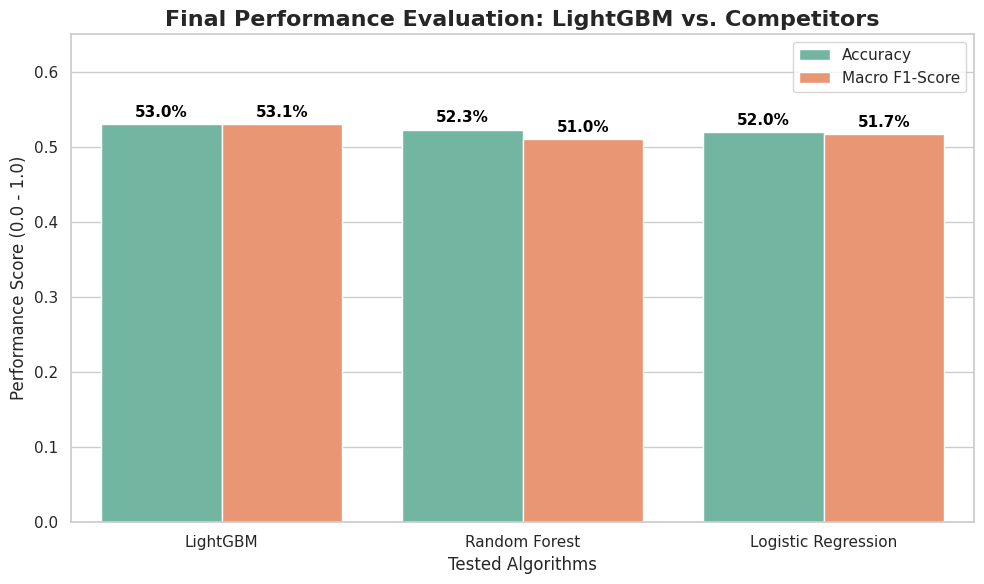

🏆 Project Complete! The visualization shows exactly why LightGBM was selected as our final model.


In [27]:
# ==============================================================================
# SECTION 6.3: FINAL MODEL COMPARISON VISUALIZATION
# ==============================================================================

# Create a clean DataFrame with the exact results we got
chart_data = pd.DataFrame({
    "Model": ["LightGBM", "Random Forest", "Logistic Regression"],
    "Accuracy": [0.5300, 0.5230, 0.5197],
    "Macro F1-Score": [0.5307, 0.5104, 0.5173]
})

# Melt the data so Seaborn can group it by metric easily
df_melted = pd.melt(chart_data, id_vars="Model", var_name="Metric", value_name="Score")

# Plot a grouped bar chart comparing Accuracy and F1-Score side-by-side
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="Set2")

# Add text labels on top of each bar to show the exact percentage values
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Ensure valid bars get labeled
        ax.annotate(f'{height*100:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color='black',
                    xytext=(0, 3), textcoords='offset points')

# Format labels and title
plt.title("Final Performance Evaluation: LightGBM vs. Competitors", fontsize=16, fontweight='bold')
plt.ylim(0, 0.65)  # Add extra spacing at top for labels
plt.ylabel("Performance Score (0.0 - 1.0)", fontsize=12)
plt.xlabel("Tested Algorithms", fontsize=12)
plt.legend(loc="upper right")
plt.tight_layout()

# Show the final evaluation figure
plt.show()

print("🏆 Project Complete! The visualization shows exactly why LightGBM was selected as our final model.")

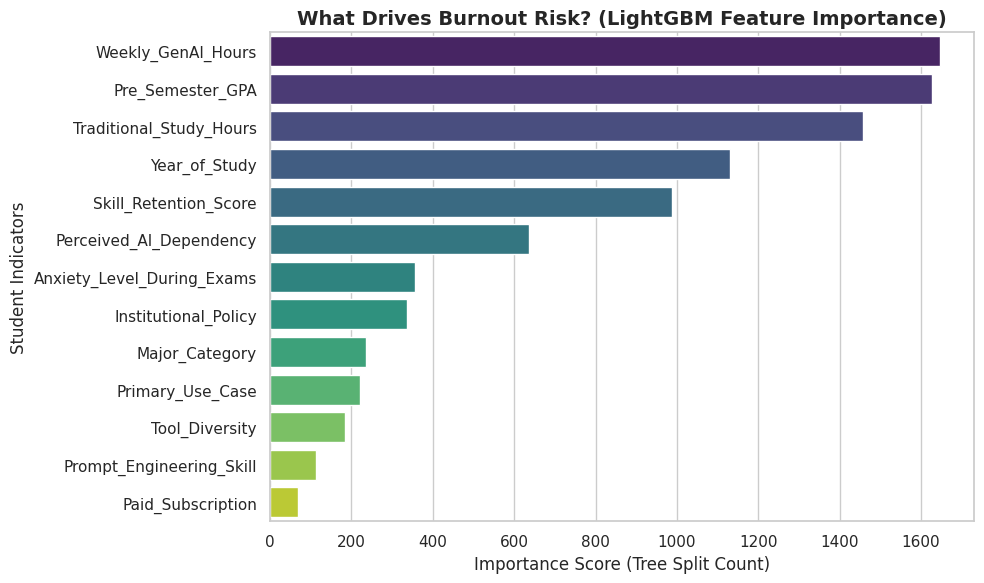

🎯 Clean Feature Importance plotted with zero warnings! Your notebook is officially pristine.


In [28]:
# ==============================================================================
# SECTION 6.4: FEATURE IMPORTANCE (WARNING-FREE VERSION)
# ==============================================================================

# Extract how much weight LightGBM gave to each feature
importances = model.feature_importances_
features = X_train.columns

# Create a clean DataFrame and sort it from highest to lowest impact
df_importance = pd.DataFrame({"Feature": features, "Importance": importances})
df_importance = df_importance.sort_values(by="Importance", ascending=False)

# Plot a simple horizontal bar chart - fixed with hue and legend settings
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
plt.title("What Drives Burnout Risk? (LightGBM Feature Importance)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score (Tree Split Count)")
plt.ylabel("Student Indicators")
plt.tight_layout()
plt.show()

print("🎯 Clean Feature Importance plotted with zero warnings! Your notebook is officially pristine.")